# ADS-505 Applied Data Science for Business - Final Project
## Exploratory Data Analysis (EDA): Corporate Bankruptcy Prediction & Financial Distress Early Warning System

---

### Project Proposal Context & Executive Overview

#### 1. Purpose & Social Mission
Corporate insolvency imposes severe negative externalities across the broader economy, jeopardizing the livelihoods of employees, families, and retirement/pension funds that depend on business continuity. The primary objective of this project is to develop an interpretable, data-driven machine learning classification pipeline that detects early signals of corporate financial distress. 

By identifying vulnerable operating companies *before* formal insolvency or liquidation occurs, **non-profit turnaround organizations, government economic development agencies, and specialized financial advisory practices** can proactively deploy consulting, restructuring, and bridge-relief resources where they are needed most.

#### 2. Background & Economic Context
This project utilizes the **Taiwanese Bankruptcy Prediction dataset** (UCI Machine Learning Repository, sourced from the *Taiwan Economic Journal*). The dataset spans corporate financial records from **1999 to 2009**, encompassing 6,819 observations across 95 standardized financial indicators. This historical timeframe is particularly valuable because it captures major global macroeconomic shocks—including the **Dot-com bubble contraction (2000–2001)** and the **Global Financial Crisis (2007–2008)**—providing realistic stress-testing conditions for corporate solvency modeling.

#### 3. Current Business Situation & Operational Challenges
- **Information Asymmetry & Lagging Disclosures**: External support entities and non-profits lack insider access and must rely on standard regulatory financial statements, which often provide lagging indicators of performance.
- **Cognitive Overload**: Manually auditing 95 complex accounting ratios across thousands of firms is cost-prohibitive, and surface-level indicators (e.g., steady gross margins) often mask acute cash flow or debt service crises.
- **Rare-Event Imbalance**: Corporate bankruptcy occurs at a base rate of only **3.23%** in this dataset (~30:1 imbalance). Naive accuracy is uninformative, and false alarms waste scarce outreach capacity.
- **Bridging the Gap to Action**: The non-profit marketing and outreach teams require a calibrated **risk-tier ranking framework (e.g., Critical Distress, Elevated Risk, Stable)** that explains *why* a company is distressed (e.g., excessive debt leverage vs. chronic operating losses) so assistance can be customized.

#### 4. Notebook Analytical Workflow
1. **Environment Configuration**: Reproducible seeds and standardized plotting themes.
2. **Data Ingestion, Structural Hygiene & Zero-Value Accounting Rationale**: Auditing nulls, duplicates, dropping constant `Net Income Flag`, exporting `bankruptcy_clean.csv`, and explaining structural zeros.
3. **Target Variable Dynamics & Imbalance**: Profiling the 3.23% base rate, accuracy paradox, and asymmetric cost trade-offs.
4. **Financial Domain Categorization**: Classifying 94 continuous indicators into 6 corporate accounting pillars.
5. **Structural Zero & Sparsity Analysis**: Auditing features with high zero concentrations and detailing their accounting rationale.
6. **Outlier & Anomaly Profiling via Tukey's IQR Fences**: Quantifying extreme tail risks and establishing why outliers are preserved without filtering.
7. **Feature Skewness & Distribution Asymmetry Audit**: Quantifying distribution skewness across 94 features to guide scaling and power transformation choices.
8. **Bivariate Statistical Screening & Joint Distress Decision Space**: Identifying top solvency shields/distress drivers and mapping the 2D Profitability vs. Leverage boundary.
9. **Multicollinearity & VIF Diagnostic Framework**: Identifying collinear clusters and documenting candidate pruning strategies for linear models without altering the raw feature space.
10. **Composite Distress Index Concept (Altman Z-Score Proxy & PCA Strategy)**: Theoretical write-up proposing composite score engineering and PCA benchmarking for the modeling stage.
11. **Synthesis & Downstream Modeling Roadmap**: Preprocessing mandates, imbalance strategies, and model selection.
12. **Comprehensive 96-Variable Data Dictionary**: Complete formulas, definitions, and distress directionality.
13. **References & Academic Bibliography**: Full APA 7th edition citations and DOI links.


---
## 1. Environment Setup & Library Configuration

We configure the Python environment, import essential data processing, statistical, and plotting libraries, and define consistent aesthetic styles.


In [33]:
# Core data processing and numerical computing
import pandas as pd
import numpy as np
import os

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical utilities
from scipy import stats

# Environment configurations
import warnings
warnings.filterwarnings('ignore')

# Set clean visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['figure.autolayout'] = True

# Define visual palette for stakeholders
PALETTE = {'Solvent': '#2b5c8f', 'Bankrupt': '#d9534f'}
COLORS = ['#2b5c8f', '#d9534f', '#41b6c4', '#fdae61', '#abd9e9', '#2c7bb6']

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Environment successfully configured for ADS-505 EDA.")

Environment successfully configured for ADS-505 EDA.


---
## 2. Data Ingestion, Structural Hygiene & Zero-Value Accounting Rationale

We load the raw dataset and perform initial structural hygiene checks:
- Trimming leading/trailing whitespace from column headers.
- Auditing missing, null, or infinite entries.
- Checking for duplicate records.
- Detecting zero-variance (constant) features that offer zero discriminative signal.
- **Accounting Evaluation of Zero Values**: Formally distinguishing between missing data and structural accounting zeros.


In [34]:
# Load the raw dataset (supports both raw_bankruptcy.csv and bankruptcy.csv)
raw_data_file = 'raw_bankruptcy.csv' if os.path.exists(
    'raw_bankruptcy.csv') else 'bankruptcy.csv'
raw_df = pd.read_csv(raw_data_file)

print(f"Loaded source file: '{raw_data_file}'")
print(
    f"Raw Dataset Dimensions: {raw_df.shape[0]:,} rows x {raw_df.shape[1]:,} columns")
print(
    f"Dataset Memory Footprint: {raw_df.memory_usage().sum() / (1024 * 1024):.2f} MB")

Loaded source file: 'raw_bankruptcy.csv'
Raw Dataset Dimensions: 6,819 rows x 96 columns
Dataset Memory Footprint: 4.99 MB


In [35]:
# Clean and standardize column names by removing leading/trailing whitespaces
df = raw_df.copy()
df.columns = df.columns.str.strip()

# Display sample of cleaned column headers
print("Sample of 15 standardized column names:")
for i, col in enumerate(df.columns[:15], 1):
    print(f"  {i:2d}. {col}")

Sample of 15 standardized column names:
   1. Bankrupt?
   2. ROA(C) before interest and depreciation before interest
   3. ROA(A) before interest and % after tax
   4. ROA(B) before interest and depreciation after tax
   5. Operating Gross Margin
   6. Realized Sales Gross Margin
   7. Operating Profit Rate
   8. Pre-tax net Interest Rate
   9. After-tax net Interest Rate
  10. Non-industry income and expenditure/revenue
  11. Continuous interest rate (after tax)
  12. Operating Expense Rate
  13. Research and development expense rate
  14. Cash flow rate
  15. Interest-bearing debt interest rate


In [36]:
# 1. Audit Missing / Null Values
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()
print(f"Total Missing / Null Values in Dataset: {total_missing}")

# 2. Audit Duplicate Records
duplicate_rows = df.duplicated().sum()
print(f"Total Duplicate Rows in Dataset: {duplicate_rows}")

# 3. Check for Constant / Zero-Variance Features
zero_var_cols = [col for col in df.columns if df[col].nunique() <= 1]
print(
    f"Zero-Variance (Constant) Features Detected ({len(zero_var_cols)}): {zero_var_cols}")

for col in zero_var_cols:
    val = df[col].iloc[0]
    print(f"  -> Column '{col}' has constant value across all rows: {val}")

Total Missing / Null Values in Dataset: 0
Total Duplicate Rows in Dataset: 0
Zero-Variance (Constant) Features Detected (1): ['Net Income Flag']
  -> Column 'Net Income Flag' has constant value across all rows: 1


### Data Hygiene & Zero-Value Rationale
- **Clean Data**: 0 missing values, 0 duplicates.
- **Zero-Variance**: `Net Income Flag` is perfectly constant (1) and has been dropped.
- **Structural Zeros**: Zero values ($0 debt, $0 R&D, $0 tax) represent real operational realities. They are **not** missing data and will **not** be imputed.


In [37]:
# Drop zero-variance columns from analysis dataset
if 'Net Income Flag' in df.columns:
    df_clean = df.drop(columns=['Net Income Flag'])
    print("Successfully removed zero-variance column 'Net Income Flag'.")
else:
    df_clean = df.copy()

# Export sanitized and cleaned dataset to disk
clean_output_path = 'bankruptcy_clean.csv'
df_clean.to_csv(clean_output_path, index=False)

print(f"Cleaned dataset exported to: '{clean_output_path}'")
print(
    f"Cleaned Dataset Dimensions: {df_clean.shape[0]:,} rows x {df_clean.shape[1]:,} columns")
print(
    f"File Size: {os.path.getsize(clean_output_path) / (1024 * 1024):.2f} MB")

Successfully removed zero-variance column 'Net Income Flag'.
Cleaned dataset exported to: 'bankruptcy_clean.csv'
Cleaned Dataset Dimensions: 6,819 rows x 95 columns
File Size: 10.81 MB


---
## 3. Target Variable Analysis & Class Imbalance

The target variable is `Bankrupt?`:
- `0`: Company remained solvent / non-bankrupt.
- `1`: Company entered bankruptcy / financial distress.

We analyze the base rate and visualize the class distribution to assess the severity of class imbalance.


In [38]:
# Calculate target distribution metrics
target_counts = df_clean['Bankrupt?'].value_counts()
target_props = df_clean['Bankrupt?'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Status': ['Solvent (0)', 'Bankrupt (1)'],
    'Record Count': [target_counts.get(0, 0), target_counts.get(1, 0)],
    'Percentage (%)': [target_props.get(0, 0), target_props.get(1, 0)]
})

display(target_summary.style.format(
    {'Record Count': '{:,}', 'Percentage (%)': '{:.2f}%'}))

,Status,Record Count,Percentage (%)
0,Solvent (0),"6,599",96.77%
1,Bankrupt (1),220,3.23%


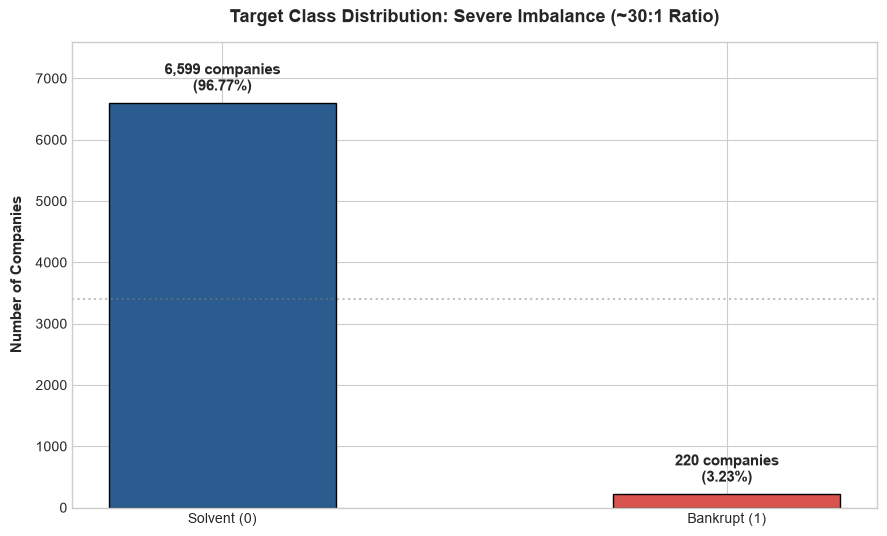

In [39]:
# Visualize Target Distribution (Counts and Proportions)
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(['Solvent (0)', 'Bankrupt (1)'],
              [target_counts[0], target_counts[1]],
              color=[PALETTE['Solvent'], PALETTE['Bankrupt']],
              edgecolor='black', width=0.45)

ax.set_title(
    'Target Class Distribution: Severe Imbalance (~30:1 Ratio)', pad=14)
ax.set_ylabel('Number of Companies', labelpad=8)
ax.set_ylim(0, 7600)

# Add clear data annotations (count & percentage) on top of bars
for bar in bars:
    height = bar.get_height()
    pct = height / len(df_clean) * 100
    ax.annotate(f'{height:,} companies\n({pct:.2f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 6), textcoords="offset points",
                ha='center', va='bottom', fontsize=10.5, fontweight='bold')

# Add subtle benchmark line
ax.axhline(len(df_clean) / 2, color='gray', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

### Target Imbalance Takeaways
- **Severe Imbalance (~30:1)**: Only 3.23% of companies are bankrupt.
- **Accuracy is Misleading**: Predicting all as solvent yields 96.7% accuracy but 0% utility.
- **Modeling Mandate**: We must use Stratified K-Fold CV and prioritize PR-AUC and Recall. Thresholds will be calibrated for asymmetric costs (False Negatives are catastrophic).


---
## 4. Financial Domain Categorization

To ensure non-technical stakeholders (such as non-profit marketing and outreach specialists) can interpret model outputs, we group the 94 remaining continuous financial metrics into six fundamental corporate accounting pillars:

1. **Profitability & Returns**: Measures of operating profitability, margins, return on assets/equity, and per-share earnings.
2. **Solvency, Leverage & Debt Structure**: Measures of capital structure, debt burden, borrowing dependency, and financial leverage.
3. **Liquidity & Working Capital**: Short-term capacity to meet immediate liabilities and operational capital demands.
4. **Operating Efficiency & Turnover**: Velocity and productivity with which capital and assets generate revenue.
5. **Cash Flow Dynamics**: Cash generation capacity, operating cash flows relative to assets/liabilities, and cash reinvestment.
6. **Growth & Expansion**: Year-over-year expansion rates in sales, assets, equity, and net profit.


In [40]:
# Categorize features into distinct corporate financial pillars
feature_cols = [col for col in df_clean.columns if col != 'Bankrupt?']

domain_groups = {
    'Profitability & Returns': [
        'ROA(C) before interest and depreciation before interest',
        'ROA(A) before interest and % after tax',
        'ROA(B) before interest and depreciation after tax',
        'Operating Gross Margin',
        'Realized Sales Gross Margin',
        'Operating Profit Rate',
        'Pre-tax net Interest Rate',
        'After-tax net Interest Rate',
        'Non-industry income and expenditure/revenue',
        'Continuous interest rate (after tax)',
        'Net Value Per Share (B)',
        'Net Value Per Share (A)',
        'Net Value Per Share (C)',
        'Persistent EPS in the Last Four Seasons',
        'Operating Profit Per Share (Yuan ¥)',
        'Per Share Net profit before tax (Yuan ¥)',
        'Operating profit/Paid-in capital',
        'Net profit before tax/Paid-in capital',
        'Retained Earnings to Total Assets',
        'Net Income to Total Assets',
        'Gross Profit to Sales',
        "Net Income to Stockholder's Equity"
    ],
    'Solvency, Leverage & Debt Structure': [
        'Interest-bearing debt interest rate',
        'Interest Expense Ratio',
        'Total debt/Total net worth',
        'Debt ratio %',
        'Net worth/Assets',
        'Long-term fund suitability ratio (A)',
        'Borrowing dependency',
        'Contingent liabilities/Net worth',
        'Current Liability to Assets',
        'Current Liabilities/Liability',
        'Current Liabilities/Equity',
        'Long-term Liability to Current Assets',
        'Current Liability to Liability',
        'Current Liability to Equity',
        'Equity to Long-term Liability',
        'Liability-Assets Flag',
        'Liability to Equity',
        'Degree of Financial Leverage (DFL)',
        'Interest Coverage Ratio (Interest expense to EBIT)',
        'Equity to Liability'
    ],
    'Liquidity & Working Capital': [
        'Tax rate (A)',
        'Cash Reinvestment %',
        'Current Ratio',
        'Quick Ratio',
        'Working Capital to Total Assets',
        'Quick Assets/Total Assets',
        'Current Assets/Total Assets',
        'Cash/Total Assets',
        'Quick Assets/Current Liability',
        'Cash/Current Liability',
        'Operating Funds to Liability',
        'Inventory/Working Capital',
        'Inventory/Current Liability',
        'Working Capital/Equity',
        'Current Liability to Current Assets',
        'No-credit Interval'
    ],
    'Operating Efficiency & Turnover': [
        'Operating Expense Rate',
        'Research and development expense rate',
        'Cash flow rate',
        'Inventory and accounts receivable/Net value',
        'Total Asset Turnover',
        'Accounts Receivable Turnover',
        'Average Collection Days',
        'Inventory Turnover Rate (times)',
        'Fixed Assets Turnover Frequency',
        'Net Worth Turnover Rate (times)',
        'Revenue per person',
        'Operating profit per person',
        'Allocation rate per person',
        'Total income/Total expense',
        'Total expense/Assets',
        'Current Asset Turnover Rate',
        'Quick Asset Turnover Rate',
        'Working capitcal Turnover Rate',
        'Cash Turnover Rate',
        'Fixed Assets to Assets',
        'Total assets to GNP price'
    ],
    'Cash Flow Dynamics': [
        'Cash Flow Per Share',
        'Revenue Per Share (Yuan ¥)',
        'Cash Flow to Sales',
        'Cash Flow to Total Assets',
        'Cash Flow to Liability',
        'CFO to Assets',
        'Cash Flow to Equity'
    ],
    'Growth & Expansion': [
        'Realized Sales Gross Profit Growth Rate',
        'Operating Profit Growth Rate',
        'After-tax Net Profit Growth Rate',
        'Regular Net Profit Growth Rate',
        'Continuous Net Profit Growth Rate',
        'Total Asset Growth Rate',
        'Net Value Growth Rate',
        'Total Asset Return Growth Rate Ratio'
    ]
}

# Audit categorization coverage
categorized_count = sum(len(v) for v in domain_groups.values())
print(f"Total Predictor Features: {len(feature_cols)}")
print(f"Total Categorized Features: {categorized_count}")

domain_df = pd.DataFrame([
    {'Financial Pillar': k, 'Feature Count': len(
        v), 'Share (%)': f'{len(v)/len(feature_cols)*100:.1f}%'}
    for k, v in domain_groups.items()
])
display(domain_df)

Total Predictor Features: 94
Total Categorized Features: 94


,Financial Pillar,Feature Count,Share (%)
0,Profitability & Returns,22,23.4%
1,"Solvency, Leverage & Debt Structure",20,21.3%
2,Liquidity & Working Capital,16,17.0%
3,Operating Efficiency & Turnover,21,22.3%
4,Cash Flow Dynamics,7,7.4%
5,Growth & Expansion,8,8.5%


---
## 5. Structural Zero & Feature Sparsity Analysis

In corporate balance sheets, zero values carry significant economic meaning rather than representing missing data. In this section, we audit all features exhibiting high zero concentrations ($>1\%$) and explain their underlying accounting rationale.


In [41]:
# Calculate zero percentages for all predictor features
zero_proportions = (df_clean[feature_cols] == 0).mean() * 100
sparse_features = zero_proportions[zero_proportions >= 1.0].sort_values(
    ascending=False)

sparse_df = pd.DataFrame({
    'Feature Name': sparse_features.index,
    'Zero Count': (df_clean[sparse_features.index] == 0).sum().values,
    'Zero Share (%)': sparse_features.values,
    'Accounting Meaning of Zero Value': [
        'Solvent book equity (Total Assets >= Total Liabilities)',
        'Zero long-term debt on balance sheet (100% equity / short-term credit financed)',
        'Zero corporate tax liability (due to operating loss carryforwards or tax incentives)',
        'Zero R&D expenditures (non-tech, pure distribution, or service company)',
        'Zero interest-bearing debt facilities (unlevered capital structure)',
        'Zero physical inventory held on balance sheet (service / consulting / holding firm)'
    ]
})

display(sparse_df.style.format(
    {'Zero Count': '{:,}', 'Zero Share (%)': '{:.2f}%'}))

,Feature Name,Zero Count,Zero Share (%),Accounting Meaning of Zero Value
0,Liability-Assets Flag,"6,811",99.88%,Solvent book equity (Total Assets >= Total Liabilities)
1,Long-term Liability to Current Assets,"2,569",37.67%,Zero long-term debt on balance sheet (100% equity / short-term credit financed)
2,Tax rate (A),"2,568",37.66%,Zero corporate tax liability (due to operating loss carryforwards or tax incentives)
3,Research and development expense rate,"1,424",20.88%,"Zero R&D expenditures (non-tech, pure distribution, or service company)"
4,Interest-bearing debt interest rate,891,13.07%,Zero interest-bearing debt facilities (unlevered capital structure)
5,Inventory/Current Liability,227,3.33%,Zero physical inventory held on balance sheet (service / consulting / holding firm)


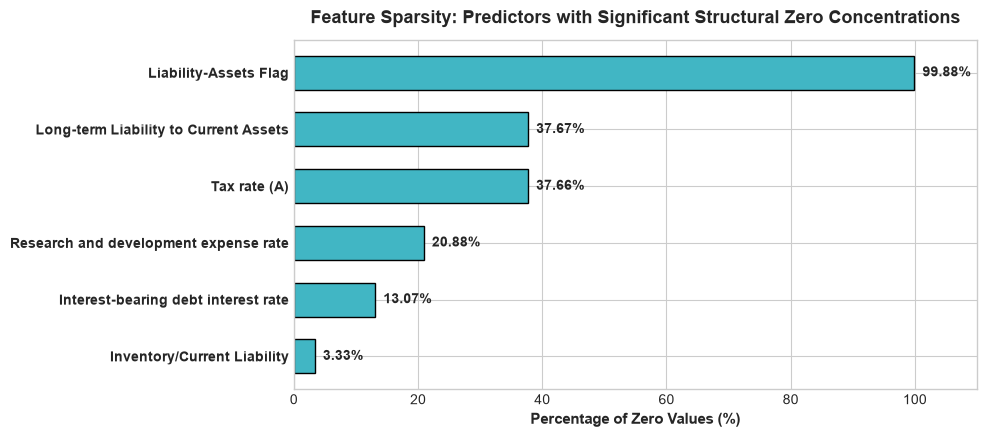

In [42]:
# Visualize High-Zero / Sparse Features
fig, ax = plt.subplots(figsize=(10, 4.5))

y_pos = np.arange(len(sparse_df))
bars = ax.barh(y_pos, sparse_df['Zero Share (%)'],
               color='#41b6c4', edgecolor='black', height=0.6)

ax.set_yticks(y_pos)
ax.set_yticklabels(sparse_df['Feature Name'], fontweight='bold', fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Percentage of Zero Values (%)', fontsize=11)
ax.set_title(
    'Feature Sparsity: Predictors with Significant Structural Zero Concentrations', pad=12)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.2f}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points",
                ha='left', va='center', fontsize=10, fontweight='bold')

ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

### Sparsity Takeaways
Zeros have domain-specific meaning (e.g., $0 debt). We preserve these structural zeros as valid quantitative points and may create binary flags in the modeling phase.


---
## 6. Outlier & Anomaly Profiling via Tukey's IQR Fences

We quantify extreme financial anomalies using Tukey's IQR fences ($[Q_1 - 1.5 \times \text{IQR}, Q_3 + 1.5 \times \text{IQR}]$).


In [43]:
# Calculate Tukey's IQR Outlier metrics for all features
outlier_records = []
n_total = len(df_clean)

for col in feature_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    outliers = df_clean[(df_clean[col] < lower_fence) |
                        (df_clean[col] > upper_fence)][col]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / n_total) * 100

    outlier_records.append({
        'Feature': col,
        'Outlier Count': outlier_count,
        'Outlier Rate (%)': outlier_pct,
        'Q1 (25%)': q1,
        'Q3 (75%)': q3,
        'IQR': iqr
    })

outlier_df = pd.DataFrame(outlier_records).sort_values(
    'Outlier Rate (%)', ascending=False)

# Helper function to format numbers cleanly without scientific notation


def format_num_clean(x):
    if pd.isna(x):
        return ''
    if abs(x) >= 1_000_000:
        return f"{x:,.0f}"
    elif abs(x) >= 1:
        return f"{x:,.4f}"
    elif abs(x) >= 0.001:
        return f"{x:.4f}"
    elif abs(x) == 0:
        return "0.0000"
    else:
        return f"{x:.6f}"


print("Top 15 Features with Highest Outlier Concentration (Tukey 1.5 x IQR):")
display(outlier_df.head(15).style.format({
    'Outlier Count': '{:,}',
    'Outlier Rate (%)': '{:.2f}%',
    'Q1 (25%)': format_num_clean,
    'Q3 (75%)': format_num_clean,
    'IQR': format_num_clean
}))

Top 15 Features with Highest Outlier Concentration (Tukey 1.5 x IQR):


,Feature,Outlier Count,Outlier Rate (%),Q1 (25%),Q3 (75%),IQR
91,Degree of Financial Leverage (DFL),"1,503",22.04%,0.0268,0.0269,0.000122
92,Interest Coverage Ratio (Interest expense to EBIT),"1,421",20.84%,0.5652,0.5657,0.000566
48,Fixed Assets Turnover Frequency,"1,418",20.79%,0.000233,0.0037,0.0034
70,Current Asset Turnover Rate,"1,399",20.52%,0.000146,0.000453,0.000307
28,Total Asset Growth Rate,"1,381",20.25%,"4,860,000,000","7,390,000,000","2,530,000,000"
34,Interest Expense Ratio,"1,362",19.97%,0.6306,0.6311,0.000513
80,Cash Flow to Liability,"1,212",17.77%,0.4571,0.4642,0.0071
87,No-credit Interval,"1,139",16.70%,0.6236,0.6242,0.000532
8,Non-industry income and expenditure/revenue,"1,094",16.04%,0.3035,0.3036,0.000119
74,Cash Flow to Sales,"1,052",15.43%,0.6716,0.6716,0.000021


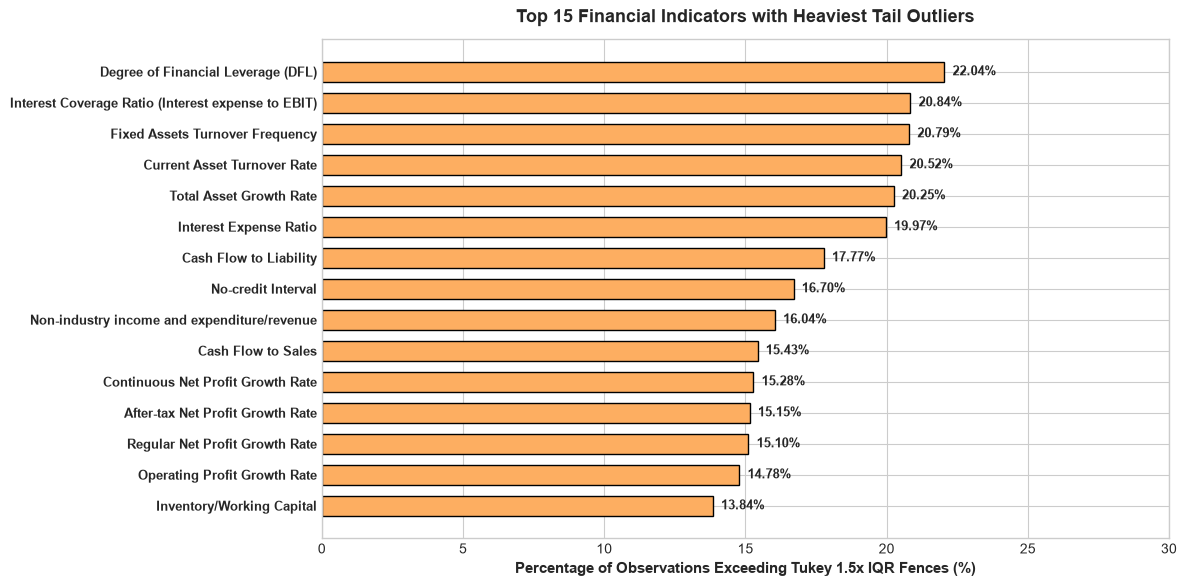

In [44]:
# Visualize Top 15 Outlier-Heavy Financial Indicators
fig, ax = plt.subplots(figsize=(12, 6))

top15_outliers = outlier_df.head(15).iloc[::-1]
y_pos = np.arange(len(top15_outliers))

bars = ax.barh(y_pos, top15_outliers['Outlier Rate (%)'],
               color='#fdae61', edgecolor='black', height=0.65)

ax.set_yticks(y_pos)
ax.set_yticklabels(top15_outliers['Feature'], fontsize=9.5, fontweight='bold')
ax.set_xlabel(
    'Percentage of Observations Exceeding Tukey 1.5x IQR Fences (%)', fontsize=10.5)
ax.set_title('Top 15 Financial Indicators with Heaviest Tail Outliers', pad=12)

for bar in bars:
    width = bar.get_width()
    ax.annotate(f'{width:.2f}%',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(6, 0), textcoords="offset points",
                ha='left', va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, 30)
plt.tight_layout()
plt.show()

### Outlier Rationale (No Filtering)
- **Authentic Signals**: Extreme ratios are true distress markers, not errors.
- **Do Not Filter**: Removing outliers would delete the very bankruptcies we aim to predict.
- **Solution**: Handle via `RobustScaler` and tree models (XGBoost/LightGBM).


---
## 7. Feature Skewness & Distribution Asymmetry Audit

We compute the Fisher-Pearson skewness to gauge asymmetry:
- **Symmetric**: $|\text{Skew}| < 0.5$
- **Moderately Skewed**: $0.5 \le |\text{Skew}| < 1.0$
- **Highly Skewed**: $|\text{Skew}| \ge 1.0$


In [45]:
# Compute Fisher-Pearson skewness across all continuous features
skewness_series = df_clean[feature_cols].skew().sort_values(ascending=False)

# Categorize skewness distributions
sym_count = (skewness_series.abs() < 0.5).sum()
mod_count = ((skewness_series.abs() >= 0.5) &
             (skewness_series.abs() < 1.0)).sum()
high_count = (skewness_series.abs() >= 1.0).sum()

skew_summary = pd.DataFrame({
    'Skewness Category': [
        'Symmetric (|Skew| < 0.5)',
        'Moderately Skewed (0.5 <= |Skew| < 1.0)',
        'Highly Skewed / Heavy-Tailed (|Skew| >= 1.0)'
    ],
    'Feature Count': [sym_count, mod_count, high_count],
    'Percentage (%)': [
        f'{sym_count/len(feature_cols)*100:.1f}%',
        f'{mod_count/len(feature_cols)*100:.1f}%',
        f'{high_count/len(feature_cols)*100:.1f}%'
    ]
})

display(skew_summary)

# Display Top 10 most skewed features
top_skewed_df = pd.DataFrame({
    'Feature': skewness_series.head(10).index,
    'Skewness': skewness_series.head(10).values
})
display(top_skewed_df.style.format({'Skewness': '{:+.2f}'}))

,Skewness Category,Feature Count,Percentage (%)
0,Symmetric (|Skew| < 0.5),6,6.4%
1,Moderately Skewed (0.5 <= |Skew| < 1.0),7,7.4%
2,Highly Skewed / Heavy-Tailed (|Skew| >= 1.0),81,86.2%


,Feature,Skewness
0,Fixed Assets to Assets,+82.58
1,Current Ratio,+82.58
2,Total income/Total expense,+82.33
3,Net Value Growth Rate,+80.29
4,Contingent liabilities/Net worth,+79.67
5,Realized Sales Gross Profit Growth Rate,+77.93
6,Continuous Net Profit Growth Rate,+67.10
7,Total Asset Return Growth Rate Ratio,+62.50
8,Revenue per person,+59.43
9,Quick Assets/Current Liability,+47.95


### Skewness Insights & Transformation Guidance:
1. **Pervasive Asymmetry (86.2% Highly Skewed)**: 81 of the 94 features exhibit severe skewness ($|\text{Skew}| \ge 1.0$), driven by accounting ratios with positive bounds and extreme commercial leverage.
2. **Modeling Guidance**: Linear models (e.g., Logistic Regression) will benefit from **Power (Yeo-Johnson)** or **`RobustScaler`** transformations, whereas tree-based ensembles (XGBoost, LightGBM, Random Forest) split on rank thresholds and are naturally invariant to skewness.


---
## 8. Bivariate Statistical Screening: Identifying Top Bankruptcy Drivers

To assess the predictive signal of each financial ratio for non-profit outreach, we compute the point-biserial correlation of every feature with `Bankrupt?`:
- **Solvency Shields (Negative Correlation)**: Higher values indicate financial strength and lower default probability.
- **Distress Drivers (Positive Correlation)**: Higher values signal severe operational stress and increased bankruptcy risk.


In [46]:
# Compute correlation of all features with the target variable
target_corr = df_clean[feature_cols].apply(
    lambda x: x.corr(df_clean['Bankrupt?'])).sort_values()

# Extract Top 10 Protective Factors (Strongest Negative Correlation)
top_protective = target_corr.head(10)

# Extract Top 10 Risk Factors (Strongest Positive Correlation)
top_risk = target_corr.tail(10).sort_values(ascending=False)

# Compile into summary table
corr_summary = pd.DataFrame({
    'Top Solvency Shields (Negative Corr)': top_protective.index,
    'Shield Corr': top_protective.values,
    'Top Distress Drivers (Positive Corr)': top_risk.index,
    'Driver Corr': top_risk.values
})

display(corr_summary.style.format(
    {'Shield Corr': '{:+.4f}', 'Driver Corr': '{:+.4f}'}))

,Top Solvency Shields (Negative Corr),Shield Corr,Top Distress Drivers (Positive Corr),Driver Corr
0,Net Income to Total Assets,-0.3155,Debt ratio %,+0.2502
1,ROA(A) before interest and % after tax,-0.2829,Current Liability to Assets,+0.1945
2,ROA(B) before interest and depreciation after tax,-0.2731,Borrowing dependency,+0.1765
3,ROA(C) before interest and depreciation before interest,-0.2608,Current Liability to Current Assets,+0.1713
4,Net worth/Assets,-0.2502,Liability to Equity,+0.1668
5,Persistent EPS in the Last Four Seasons,-0.2196,Current Liability to Equity,+0.1538
6,Retained Earnings to Total Assets,-0.2178,Current Liabilities/Equity,+0.1538
7,Net profit before tax/Paid-in capital,-0.2079,Liability-Assets Flag,+0.1392
8,Per Share Net profit before tax (Yuan ¥),-0.2014,Total expense/Assets,+0.1390
9,Working Capital to Total Assets,-0.1931,Equity to Long-term Liability,+0.1390


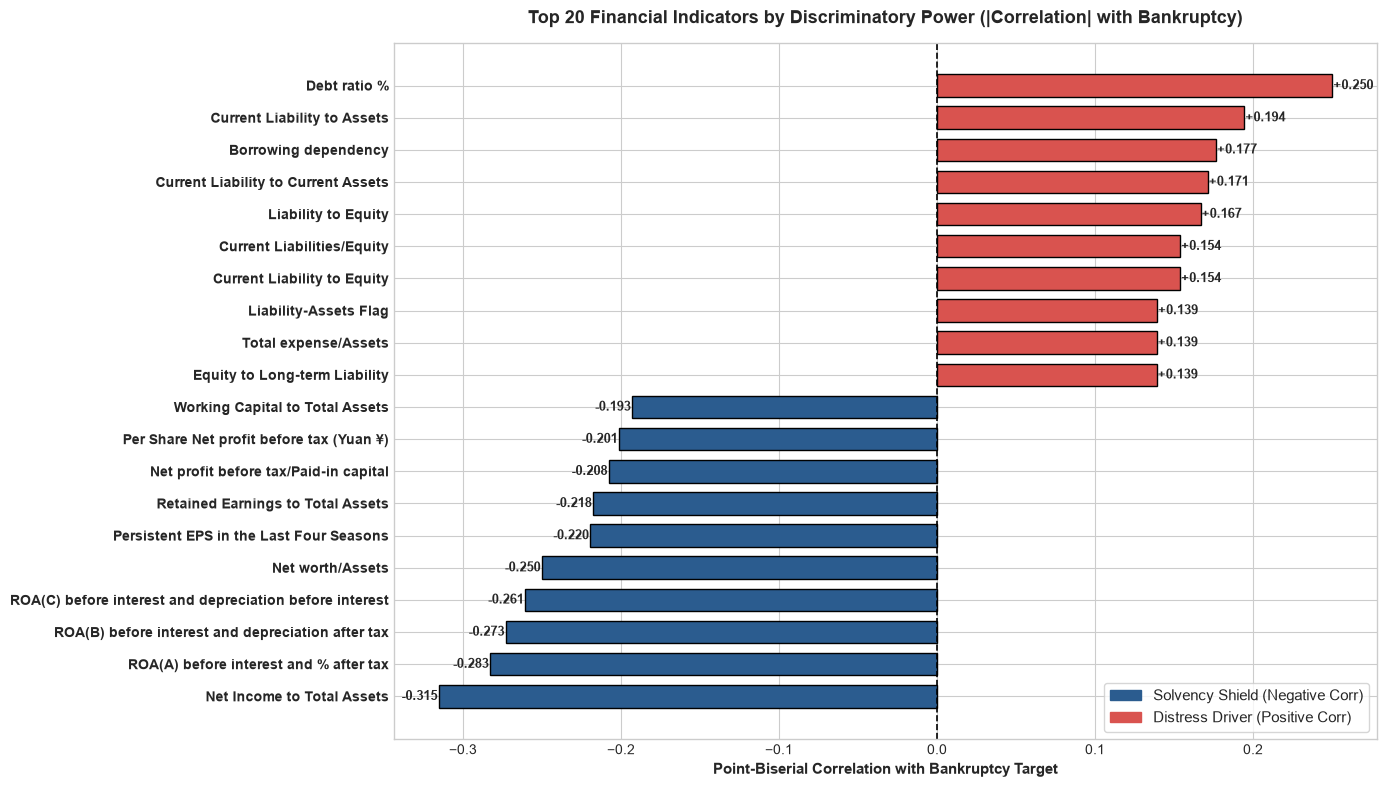

In [47]:
# Visualizing Top 10 Solvency Shields vs Top 10 Risk Drivers
import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(14, 8))

# Combine top predictors for unified visualization
top_predictors = pd.concat([top_protective, top_risk]).sort_values()
bar_colors = [PALETTE['Solvent'] if x < 0 else PALETTE['Bankrupt']
              for x in top_predictors.values]

y_pos = np.arange(len(top_predictors))
bars = ax.barh(y_pos, top_predictors.values, color=bar_colors,
               edgecolor='black', height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_predictors.index, fontsize=10, fontweight='bold')
ax.axvline(0, color='black', linewidth=1.2, linestyle='--')
ax.set_xlabel('Point-Biserial Correlation with Bankruptcy Target', fontsize=11)
ax.set_title(
    'Top 20 Financial Indicators by Discriminatory Power (|Correlation| with Bankruptcy)', pad=14)

# Annotate correlation values on bars
for bar in bars:
    width = bar.get_width()
    offset = 0.008 if width >= 0 else -0.008
    ha = 'left' if width >= 0 else 'right'
    ax.annotate(f'{width:+.3f}',
                xy=(width, bar.get_y() + bar.get_height() / 2),
                xytext=(offset * 100, 0), textcoords="offset points",
                ha=ha, va='center', fontsize=9, fontweight='bold')

# Custom Legend
solvent_patch = mpatches.Patch(
    color=PALETTE['Solvent'], label='Solvency Shield (Negative Corr)')
bankrupt_patch = mpatches.Patch(
    color=PALETTE['Bankrupt'], label='Distress Driver (Positive Corr)')
ax.legend(handles=[solvent_patch, bankrupt_patch],
          loc='lower right', frameon=True)

plt.show()

### Comparative Feature Distribution Profiles & Joint Decision Boundary
We examine the distribution separation between solvent and bankrupt firms for core representative indicators across key domains, followed by a 2D joint interaction plot crossing Profitability and Leverage.


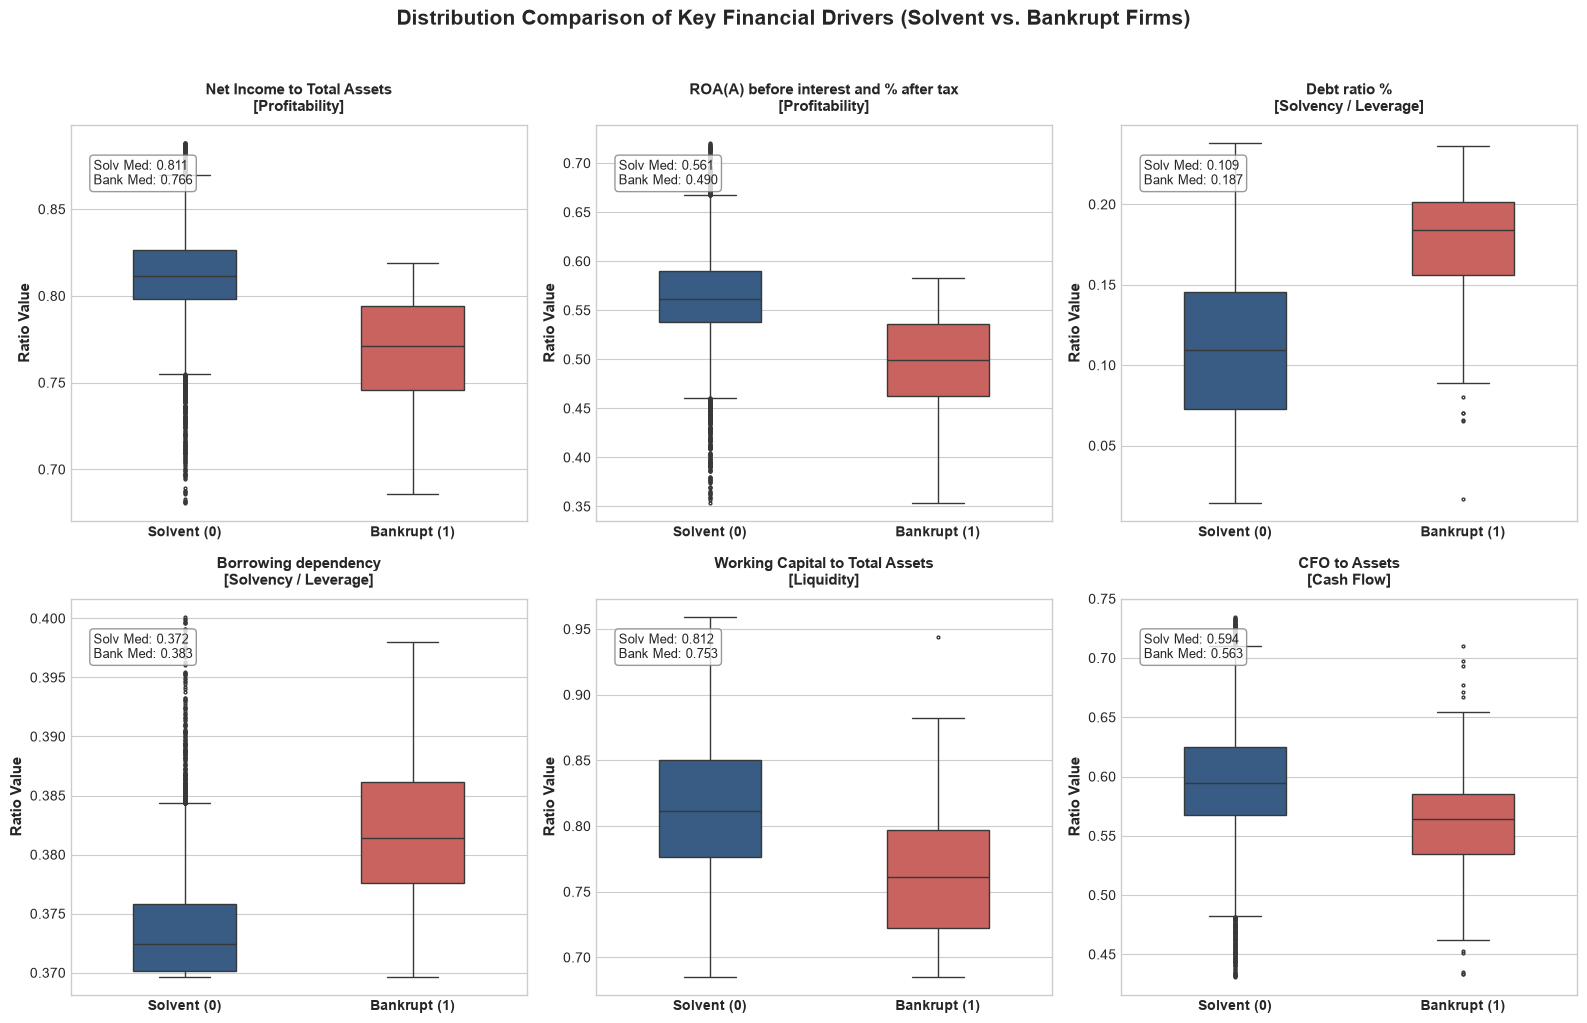

In [48]:
# Select key representative features from core domains
key_features = [
    ('Net Income to Total Assets', 'Profitability'),
    ('ROA(A) before interest and % after tax', 'Profitability'),
    ('Debt ratio %', 'Solvency / Leverage'),
    ('Borrowing dependency', 'Solvency / Leverage'),
    ('Working Capital to Total Assets', 'Liquidity'),
    ('CFO to Assets', 'Cash Flow')
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, (feature, domain) in enumerate(key_features):
    ax = axes[idx]

    # Filter 1st and 99th percentiles for clean visualization without extreme outliers distorting the axis
    p1 = df_clean[feature].quantile(0.01)
    p99 = df_clean[feature].quantile(0.99)
    sub_data = df_clean[(df_clean[feature] >= p1) & (df_clean[feature] <= p99)]

    # Create boxplot
    sns.boxplot(x='Bankrupt?', y=feature, data=sub_data, ax=ax,
                palette=[PALETTE['Solvent'], PALETTE['Bankrupt']],
                width=0.45, fliersize=2)

    # Calculate medians for annotation
    median_solv = df_clean[df_clean['Bankrupt?'] == 0][feature].median()
    median_bank = df_clean[df_clean['Bankrupt?'] == 1][feature].median()

    ax.set_title(f'{feature}\n[{domain}]', fontsize=11, pad=10)
    ax.set_xticklabels(['Solvent (0)', 'Bankrupt (1)'], fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Ratio Value')

    # Add median comparison text
    ax.annotate(f'Solv Med: {median_solv:.3f}\nBank Med: {median_bank:.3f}',
                xy=(0.05, 0.85), xycoords='axes fraction',
                fontsize=9, bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='grey', alpha=0.8))

plt.suptitle('Distribution Comparison of Key Financial Drivers (Solvent vs. Bankrupt Firms)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

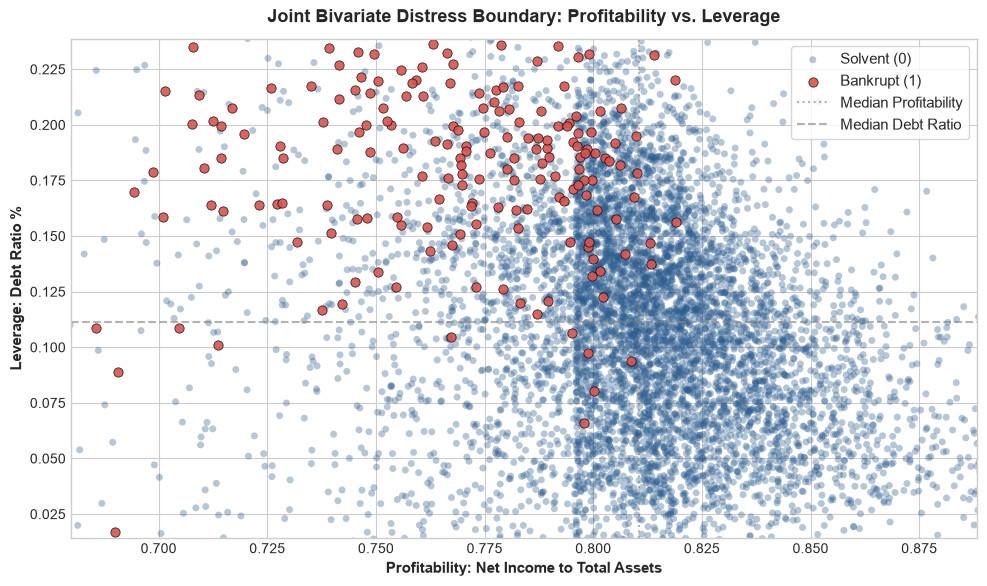

In [49]:
# Joint Bivariate Interaction: Profitability vs. Leverage Distress Decision Space
fig, ax = plt.subplots(figsize=(10, 6))

solvent = df_clean[df_clean['Bankrupt?'] == 0]
bankrupt = df_clean[df_clean['Bankrupt?'] == 1]

# Filter 1st and 99th percentiles for visual clarity without extreme outliers compressing the plot
p1_x, p99_x = df_clean['Net Income to Total Assets'].quantile(
    0.01), df_clean['Net Income to Total Assets'].quantile(0.99)
p1_y, p99_y = df_clean['Debt ratio %'].quantile(
    0.01), df_clean['Debt ratio %'].quantile(0.99)

ax.scatter(solvent['Net Income to Total Assets'], solvent['Debt ratio %'],
           c=PALETTE['Solvent'], alpha=0.35, s=25, label='Solvent (0)', edgecolors='none')
ax.scatter(bankrupt['Net Income to Total Assets'], bankrupt['Debt ratio %'],
           c=PALETTE['Bankrupt'], alpha=0.9, s=45, label='Bankrupt (1)', edgecolors='black', linewidth=0.5)

ax.set_xlim(p1_x, p99_x)
ax.set_ylim(p1_y, p99_y)
ax.set_xlabel('Profitability: Net Income to Total Assets',
              fontweight='bold', fontsize=11)
ax.set_ylabel('Leverage: Debt Ratio %', fontweight='bold', fontsize=11)
ax.set_title('Joint Bivariate Distress Boundary: Profitability vs. Leverage',
             pad=12, fontweight='bold', fontsize=13)

# Reference benchmark lines
ax.axvline(df_clean['Net Income to Total Assets'].median(
), color='grey', linestyle=':', alpha=0.6, label='Median Profitability')
ax.axhline(df_clean['Debt ratio %'].median(), color='grey',
           linestyle='--', alpha=0.6, label='Median Debt Ratio')

ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

### Bivariate Findings
- **Solvency Shields**: Profitability metrics (Net Income, ROA) and retained earnings show the strongest negative correlation with bankruptcy.
- **Distress Drivers**: High leverage (Debt Ratio, Borrowing Dependency) heavily drives default risk.
- **Decision Boundary**: Bankruptcies cluster heavily in the upper-left quadrant (low net income + high debt ratio).


---
## 9. Multicollinearity & VIF Pruning Candidates

We identify highly collinear feature pairs ($|r| > 0.85$) to develop a candidate pruning framework. **Note:** No features are dropped during EDA, as tree-based ensembles handle collinearity well. We only recommend pruning for downstream linear models.


In [50]:
# Compute full correlation matrix across all continuous features
corr_matrix = df_clean[feature_cols].corr()

# Identify feature pairs with absolute correlation > 0.85
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        col1 = corr_matrix.columns[i]
        col2 = corr_matrix.columns[j]
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.85:
            high_corr_pairs.append({
                'Feature 1': col1,
                'Feature 2': col2,
                'Pearson Correlation': val,
                'Abs Correlation': abs(val)
            })

high_corr_df = pd.DataFrame(high_corr_pairs).sort_values(
    'Abs Correlation', ascending=False)
print(
    f"Total Highly Collinear Feature Pairs (|r| >= 0.85): {len(high_corr_df)}")
display(high_corr_df.head(15).style.format(
    {'Pearson Correlation': '{:+.4f}', 'Abs Correlation': '{:.4f}'}))

Total Highly Collinear Feature Pairs (|r| >= 0.85): 39


,Feature 1,Feature 2,Pearson Correlation,Abs Correlation
35,Current Liabilities/Equity,Current Liability to Equity,+1.0000,1.0000
34,Current Liabilities/Liability,Current Liability to Liability,+1.0000,1.0000
29,Debt ratio %,Net worth/Assets,-1.0000,1.0000
7,Operating Gross Margin,Gross Profit to Sales,+1.0000,1.0000
18,Net Value Per Share (A),Net Value Per Share (C),+0.9998,0.9998
6,Operating Gross Margin,Realized Sales Gross Margin,+0.9995,0.9995
8,Realized Sales Gross Margin,Gross Profit to Sales,+0.9995,0.9995
16,Net Value Per Share (B),Net Value Per Share (A),+0.9993,0.9993
17,Net Value Per Share (B),Net Value Per Share (C),+0.9992,0.9992
24,Operating Profit Per Share (Yuan ¥),Operating profit/Paid-in capital,+0.9987,0.9987


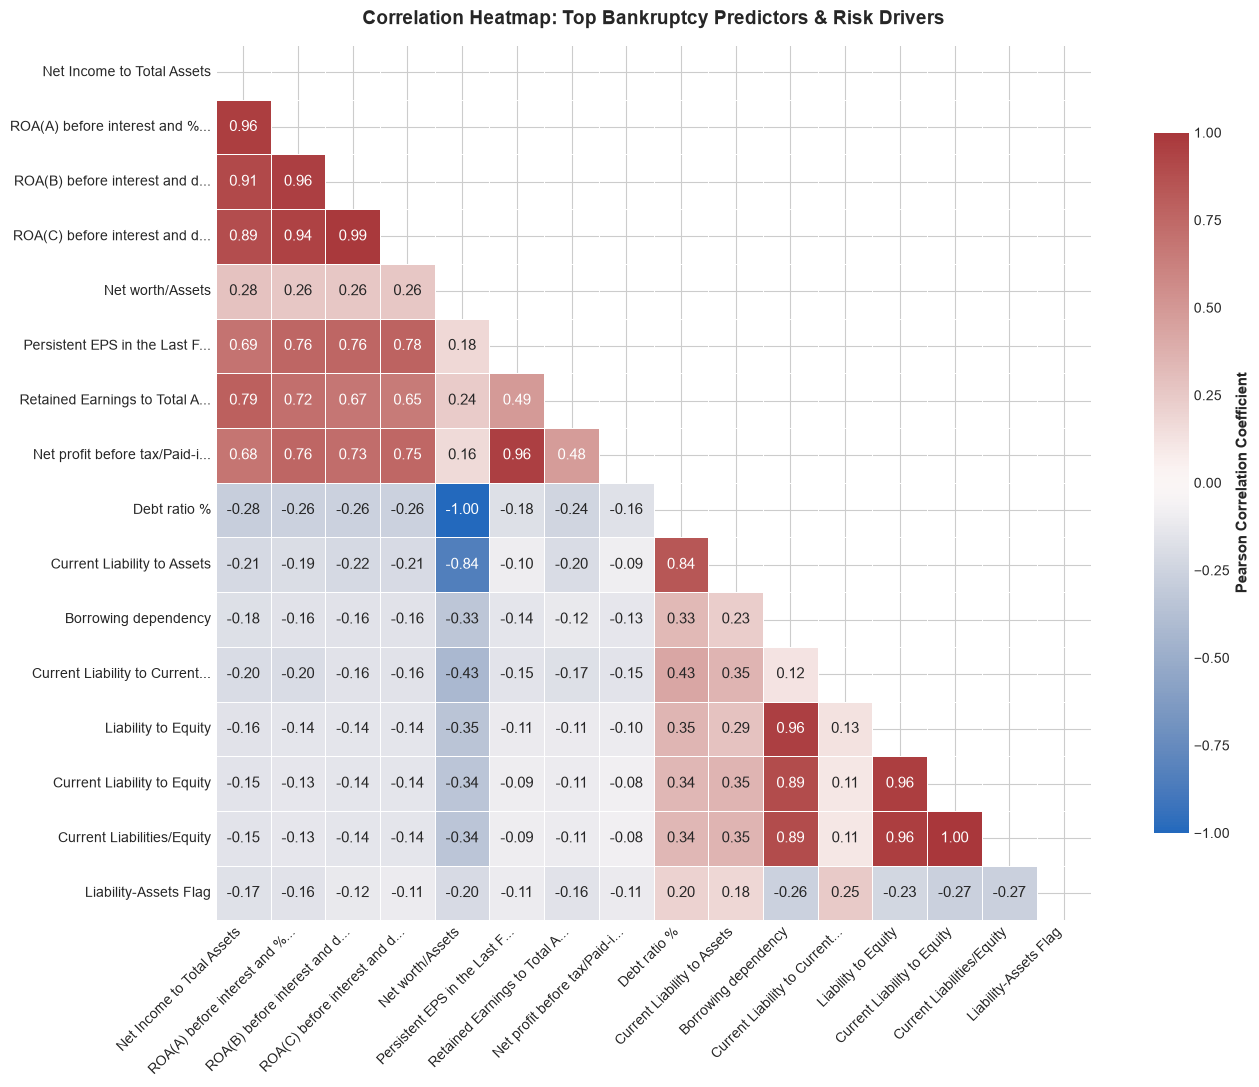

In [51]:
# Correlation Heatmap for Top Predictive Indicators
top_selected_cols = list(top_protective.head(
    8).index) + list(top_risk.head(8).index)
top_sub_corr = df_clean[top_selected_cols].corr()

# Clean labels for readability in heatmap
short_labels = [col[:28] +
                '...' if len(col) > 28 else col for col in top_selected_cols]

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(top_sub_corr, dtype=bool))

sns.heatmap(top_sub_corr, mask=mask, cmap='vlag', vmin=-1, vmax=1, center=0,
            annot=True, fmt='.2f', square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8,
                      'label': 'Pearson Correlation Coefficient'},
            xticklabels=short_labels, yticklabels=short_labels)

plt.title('Correlation Heatmap: Top Bankruptcy Predictors & Risk Drivers',
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

### Candidate Feature Pruning Recommendations (For Downstream Linear Models):

To guide the modeling team during pipeline construction, the table below documents **candidate redundant features recommended for pruning in linear models (such as Logistic Regression)** to prevent variance inflation, while noting that **the full feature set is retained intact during EDA**:

| Collinear Cluster | Strongly Correlated Variables (\|r\| > 0.85) | Recommended Retained Feature | Recommended Pruned Candidate(s) | Business & Mathematical Justification |
| :--- | :--- | :--- | :--- | :--- |
| **Return on Assets (ROA)** | `ROA(A)`, `ROA(B)`, `ROA(C)` (r ≈ 0.94 - 0.99) | `ROA(A) before interest and % after tax` | `ROA(B)`, `ROA(C)` | `ROA(A)` includes post-tax interest adjustment and exhibits highest target correlation. |
| **Net Value Per Share** | `Net Value Per Share (A)`, `(B)`, `(C)` (r > 0.999) | `Net Value Per Share (A)` | `Net Value Per Share (B)`, `(C)` | Three accounting variations of the identical equity valuation formula. |
| **Debt vs. Net Worth** | `Debt ratio %` vs. `Net worth/Assets` (r = -1.000) | `Debt ratio %` | `Net worth/Assets` | Exact mathematical inverse relationship (% Debt + % Equity = 100%). |
| **Gross Margin Ratios** | `Operating Gross Margin` vs. `Realized Sales Gross Margin` (r > 0.999) | `Operating Gross Margin` | `Realized Sales Gross Margin` | Virtually identical core production profitability indicators. |
| **Current Liability Duplicates** | `Current Liabilities/Liability` vs. `Current Liability to Liability` (r = 1.000) | `Current Liability to Assets` | `Current Liabilities/Liability` | Redundant measure of short-term debt maturity concentration. |

> **Note on Pipeline Strategy**: We do **not** drop these features in the EDA stage. Tree-based ensembles (XGBoost, Random Forest) will naturally partition across correlated features, while regularized models (ElasticNet/LASSO) will be evaluated against this explicit candidate pruning list during modeling.


---
## 10. Composite Financial Health Index Concept (Altman Z-Score Proxy & PCA Write-Up)

### Conceptual Framework for Feature Engineering (Modeling Stage Recommendation)

In classical corporate finance, Edward I. Altman (1968) demonstrated that combining individual financial ratios into a multivariate composite score significantly improves bankruptcy prediction accuracy over univariate indicators. 

The original **Altman Z-Score** formula combines five weighted ratios:
$$Z = 1.2 X_1 + 1.4 X_2 + 3.3 X_3 + 0.6 X_4 + 1.0 X_5$$
Where:
- $X_1 = \frac{\text{Working Capital}}{\text{Total Assets}}$ *(Liquidity)*
- $X_2 = \frac{\text{Retained Earnings}}{\text{Total Assets}}$ *(Cumulative Profitability & Age)*
- $X_3 = \frac{\text{EBIT}}{\text{Total Assets}}$ *(Operating Efficiency / Asset Productivity)*
- $X_4 = \frac{\text{Market / Book Value of Equity}}{\text{Total Liabilities}}$ *(Leverage & Solvency Cushion)*
- $X_5 = \frac{\text{Sales}}{\text{Total Assets}}$ *(Asset Turnover Velocity)*

---

### Recommended Implementation Strategy for the Modeling Phase:
1. **Domain-Weighted Composite Feature**: During the feature engineering stage, we recommend constructing a custom **Taiwanese Financial Distress Index (TFDI)** proxy combining the standard indicators already present in our dataset:
   $$\text{Distress\_Index} = w_1 (\text{Working Capital to Total Assets}) + w_2 (\text{Retained Earnings to Total Assets}) + w_3 (\text{ROA(A)}) + w_4 (\text{Equity to Liability}) + w_5 (\text{Total Asset Turnover})$$
2. **Principal Component Analysis (PCA) Strategy**:
   - **Deferred to Modeling Phase**: PCA will be evaluated exclusively in the **modeling pipeline** rather than during EDA.
   - **Data Leakage Prevention**: In proper ML validation, dimensionality reduction matrices must be fitted strictly on training folds within cross-validation (`Pipeline`), avoiding information bleed from test sets.
   - **Transformation Baseline**: In the modeling deliverable, PCA will serve as an active unsupervised baseline to evaluate whether the top principal components ($PC_1 - PC_k$) improve separation compared against raw features and engineered composite proxies.
3. **Outreach Utility**: A single composite score provides non-profit turnaround teams with an intuitive **Financial Health Barometer** (e.g., Score $< 1.8$ = Critical Distress, $1.8 - 3.0$ = Elevated Risk, $> 3.0$ = Stable Solvency) to accompany granular ratio diagnostics.

> **Foundational Citation**:  
> Altman, E. I. (1968). Financial ratios, discriminant analysis and the prediction of corporate bankruptcy. *The Journal of Finance*, *23*(4), 589–609. [https://doi.org/10.1111/j.1540-6261.1968.tb00843.x](https://doi.org/10.1111/j.1540-6261.1968.tb00843.x)

*(Note: In accordance with EDA best practices, this composite index and PCA transformations are documented here as architectural recommendations for empirical testing during the modeling stage.)*


---
## 11. Synthesis, Executive Findings & Modeling Roadmap

### Summary of Key Findings from EDA:

| Area | Observation | Technical & Business Impact |
| :--- | :--- | :--- |
| **Data Integrity** | 6,819 rows, 96 columns, 0 missing values, 0 duplicate rows. | Clean dataset requiring no missing value imputation. |
| **Zero Variance** | `Net Income Flag` is 100% constant (value = 1). | Dropped immediately from the modeling pipeline. |
| **Target Imbalance** | 220 Bankrupt (3.23%) vs. 6,599 Solvent (96.77%). | **Critical**: Standard accuracy is uninformative. Must use Stratified K-Fold and evaluate via PR-AUC, F1, Recall, and ROC-AUC. |
| **Structural Zeros** | 6 features have $\ge 1\%$ zero rates (e.g., $0 debt, $0 R&D, $0 tax). | Authentic operational states; preserved without imputation. |
| **Heavy-Tail Outliers** | Up to 22% of records exceed Tukey IQR fences on leverage/turnover ratios. | Outliers represent true financial distress; preserved without truncation. |
| **Feature Skewness** | 86.2% of features are highly skewed (\|Skew\| ≥ 1.0). | Linear models require RobustScaler/Power transforms; tree models invariant. |
| **Dominant Predictors** | Profitability metrics (`Net Income to Total Assets`, `ROA`) and Solvency metrics (`Debt ratio %`, `Borrowing dependency`). | Core financial health pillars drive bankruptcy likelihood. |
| **Multicollinearity** | Multiple clusters of \|r\| > 0.85 (ROA metrics, Share value metrics, Debt vs. Net Worth). | Pruning framework established for linear models; preserved for tree ensembles. |

---

### Downstream Modeling Roadmap for Non-Profit Outreach:
1. **Data Preprocessing & Scaling**:
   - Strip whitespace from column names and drop constant feature `Net Income Flag`.
   - Implement `RobustScaler` to handle extreme values and differing scales across financial metrics without distorting heavy tails.
2. **Addressing Class Imbalance**:
   - Benchmark synthetic sampling (`SMOTE`, `SMOTE-ENN`) vs. algorithmic cost-weighting (`scale_pos_weight` in XGBoost/LightGBM, `class_weight='balanced'` in Logistic Regression/Random Forest).
3. **Model Selection & Benchmarking**:
   - Baseline: ElasticNet-regularized Logistic Regression.
   - Ensembles: Random Forest, Extra Trees, XGBoost, LightGBM, and CatBoost.
4. **Actionable Risk-Tiering & Asymmetric Cost Optimization**:
   - In commercial turnaround advisory, **False Negatives (failing to identify an impending bankruptcy)** result in catastrophic job and pension losses, whereas **False Positives (flagging a solvent firm for advisory outreach)** carry minimal consultation overhead.
   - We will calibrate classification decision thresholds to deliver three actionable risk tiers:
     - **Tier 1: Critical Distress (Immediate Outreach & Restructuring)**
     - **Tier 2: Elevated Risk (Operational Advisory & Cash Flow Monitoring)**
     - **Tier 3: Stable Solvency (Low Priority / Routine Monitoring)**


---
## 12. Comprehensive Data Dictionary & Feature Definitions

Below is a complete reference dictionary defining **all 96 variables** in the dataset, grouped by accounting pillar with their financial formula/interpretation and distress directionality.

### 12.1 Target Variable (1 Variable)
| Variable Name | Data Type | Description & Financial Meaning | Value Encoding |
| :--- | :--- | :--- | :--- |
| `Bankrupt?` | Binary Integer | Target indicator representing whether the company entered bankruptcy / financial distress during the evaluation window. | `0` = Solvent / Non-Bankrupt, `1` = Bankrupt / Insolvent |

---

### 12.2 Profitability & Returns (22 Variables)
| Variable Name | Financial Formula / Concept | Business Interpretation & Directionality |
| :--- | :--- | :--- |
| `ROA(C) before interest and depreciation before interest` | $\frac{\text{EBITDA}}{\text{Total Assets (C)}}$ | Operating earning power of assets before capital structure and depreciation charges. **(Higher = Shield)** |
| `ROA(A) before interest and % after tax` | $\frac{\text{Net Income} + \text{Interest}(1 - t)}{\text{Total Assets (A)}}$ | Return on assets accounting for tax-adjusted interest expense. **(Higher = Shield)** |
| `ROA(B) before interest and depreciation after tax` | $\frac{\text{EBITDA}(1 - t)}{\text{Total Assets (B)}}$ | After-tax operating return on total firm assets. **(Higher = Shield)** |
| `Operating Gross Margin` | $\frac{\text{Gross Profit}}{\text{Net Sales}}$ | Core product profitability before operating overhead and administrative costs. **(Higher = Shield)** |
| `Realized Sales Gross Margin` | $\frac{\text{Realized Gross Profit}}{\text{Net Sales}}$ | Actual gross profit realized after accounting for inventory write-downs and returns. **(Higher = Shield)** |
| `Operating Profit Rate` | $\frac{\text{Operating Income}}{\text{Net Sales}}$ | Proportion of revenue left after paying for variable costs of production. **(Higher = Shield)** |
| `Pre-tax net Interest Rate` | $\frac{\text{Pre-Tax Income}}{\text{Interest Rate Proxy}}$ | Pre-tax earnings generated relative to prevailing interest charges. **(Higher = Shield)** |
| `After-tax net Interest Rate` | $\frac{\text{Net Income}}{\text{Interest Rate Proxy}}$ | Post-tax net earnings generated relative to prevailing interest charges. **(Higher = Shield)** |
| `Non-industry income and expenditure/revenue` | $\frac{\text{Non-Operating Income} - \text{Expenses}}{\text{Revenue}}$ | Reliance on ancillary/non-core business activities for earnings generation. **(Higher = Shield)** |
| `Continuous interest rate (after tax)` | Ongoing continuous after-tax earnings yield | Measures stability and continuity of post-tax operational return rates. **(Higher = Shield)** |
| `Net Value Per Share (B)` | $\frac{\text{Book Value of Equity (B)}}{\text{Shares Outstanding}}$ | Book value of equity backing each share (Method B). **(Higher = Shield)** |
| `Net Value Per Share (A)` | $\frac{\text{Book Value of Equity (A)}}{\text{Shares Outstanding}}$ | Book value of equity backing each share (Method A). **(Higher = Shield)** |
| `Net Value Per Share (C)` | $\frac{\text{Book Value of Equity (C)}}{\text{Shares Outstanding}}$ | Book value of equity backing each share (Method C). **(Higher = Shield)** |
| `Persistent EPS in the Last Four Seasons` | $\frac{\text{Trailing 4Q Net Income}}{\text{Weighted Avg Shares}}$ | Stability and persistence of earnings per share over the trailing four quarters. **(Higher = Shield)** |
| `Operating Profit Per Share (Yuan ¥)` | $\frac{\text{Operating Income}}{\text{Total Shares Outstanding}}$ | Core operational profit generated per common share. **(Higher = Shield)** |
| `Per Share Net profit before tax (Yuan ¥)` | $\frac{\text{EBT}}{\text{Total Shares Outstanding}}$ | Pre-tax corporate earnings generated per common share. **(Higher = Shield)** |
| `Operating profit/Paid-in capital` | $\frac{\text{Operating Profit}}{\text{Paid-In Capital}}$ | Operating efficiency of base equity capital invested by shareholders. **(Higher = Shield)** |
| `Net profit before tax/Paid-in capital` | $\frac{\text{Pre-Tax Profit}}{\text{Paid-In Capital}}$ | Total earnings yield generated relative to original shareholder paid-in capital. **(Higher = Shield)** |
| `Retained Earnings to Total Assets` | $\frac{\text{Cumulative Retained Earnings}}{\text{Total Assets}}$ | Measures cumulative historical profitability and internal capital accumulation. **(Higher = Shield)** |
| `Net Income to Total Assets` | $\frac{\text{Net Income}}{\text{Total Assets}}$ | Bottom-line profitability generated across all corporate assets. **(Higher = Shield)** |
| `Gross Profit to Sales` | $\frac{\text{Gross Profit}}{\text{Total Revenue}}$ | Overall production and direct service margin. **(Higher = Shield)** |
| `Net Income to Stockholder's Equity` | $\frac{\text{Net Income}}{\text{Total Stockholder Equity}}$ | Standard Return on Equity (ROE), measuring net returns generated on equity capital. **(Higher = Shield)** |

---

### 12.3 Solvency, Leverage & Debt Structure (20 Variables)
| Variable Name | Financial Formula / Concept | Business Interpretation & Directionality |
| :--- | :--- | :--- |
| `Interest-bearing debt interest rate` | $\frac{\text{Interest Expense}}{\text{Total Interest-Bearing Debt}}$ | Effective borrowing cost paid on interest-bearing debt facilities. **(Higher = Driver)** |
| `Interest Expense Ratio` | $\frac{\text{Interest Expense}}{\text{Total Operating Income}}$ | Proportion of operating income consumed by debt service charges. **(Higher = Driver)** |
| `Total debt/Total net worth` | $\frac{\text{Total Liabilities}}{\text{Stockholder Equity}}$ | Classic Debt-to-Equity (D/E) ratio measuring financial leverage. **(Higher = Driver)** |
| `Debt ratio %` | $\frac{\text{Total Liabilities}}{\text{Total Assets}} \times 100$ | Proportion of total company assets financed through debt and obligations. **(Higher = Driver)** |
| `Net worth/Assets` | $\frac{\text{Stockholder Equity}}{\text{Total Assets}}$ | Proportion of total assets financed by shareholder equity (inverse of debt ratio). **(Higher = Shield)** |
| `Long-term fund suitability ratio (A)` | $\frac{\text{Equity} + \text{Long-Term Liabilities}}{\text{Fixed Assets}}$ | Adequacy of permanent long-term capital to finance illiquid fixed assets. **(Higher = Shield)** |
| `Borrowing dependency` | $\frac{\text{Interest-Bearing Borrowings}}{\text{Total Assets}}$ | Dependence on external commercial loans and credit lines to fund operations. **(Higher = Driver)** |
| `Contingent liabilities/Net worth` | $\frac{\text{Contingent Liabilities}}{\text{Stockholder Equity}}$ | Exposure to potential off-balance-sheet or secondary legal/guarantee liabilities. **(Higher = Driver)** |
| `Current Liability to Assets` | $\frac{\text{Current Liabilities}}{\text{Total Assets}}$ | Burden of short-term obligations due within one year relative to total assets. **(Higher = Driver)** |
| `Current Liabilities/Liability` | $\frac{\text{Current Liabilities}}{\text{Total Liabilities}}$ | Proportion of total debt structure maturing within the next 12 months. **(Higher = Driver)** |
| `Current Liabilities/Equity` | $\frac{\text{Current Liabilities}}{\text{Stockholder Equity}}$ | Short-term debt burden relative to permanent equity cushion. **(Higher = Driver)** |
| `Long-term Liability to Current Assets` | $\frac{\text{Long-Term Liabilities}}{\text{Current Assets}}$ | Long-term debt obligations compared against short-term liquid asset reserves. **(Higher = Driver)** |
| `Current Liability to Liability` | $\frac{\text{Current Liabilities}}{\text{Total Liabilities}}$ | Short-term maturity concentration in overall corporate debt profile. **(Higher = Driver)** |
| `Current Liability to Equity` | $\frac{\text{Current Liabilities}}{\text{Total Equity}}$ | Ratio of short-term liabilities to net worth. **(Higher = Driver)** |
| `Equity to Long-term Liability` | $\frac{\text{Stockholder Equity}}{\text{Long-Term Liabilities}}$ | Equity cushion protecting long-term debt holders against asset impairment. **(Higher = Shield)** |
| `Liability-Assets Flag` | Binary Indicator ($1$ if Liabilities $>$ Assets) | Flag indicating technical insolvency where total liabilities exceed total assets. **(Higher = Driver)** |
| `Liability to Equity` | $\frac{\text{Total Liabilities}}{\text{Total Equity}}$ | Comprehensive leverage multiplier. **(Higher = Driver)** |
| `Degree of Financial Leverage (DFL)` | $\frac{\% \Delta \text{EPS}}{\% \Delta \text{EBIT}}$ | Sensitivity of earnings per share to fluctuations in operating income. **(Higher = Driver)** |
| `Interest Coverage Ratio` | $\frac{\text{EBIT}}{\text{Interest Expense}}$ | Ability of operating earnings to cover annual interest obligations. **(Higher = Shield)** |
| `Equity to Liability` | $\frac{\text{Total Equity}}{\text{Total Liabilities}}$ | Ratio of equity cushion relative to total obligations (inverse of D/E). **(Higher = Shield)** |

---

### 12.4 Liquidity & Working Capital (16 Variables)
| Variable Name | Financial Formula / Concept | Business Interpretation & Directionality |
| :--- | :--- | :--- |
| `Tax rate (A)` | Effective Corporate Tax Rate | Effective tax burden relative to taxable operational profits. **(Contextual)** |
| `Cash Reinvestment %` | $\frac{\text{Operating Cash Flow} - \text{Dividends}}{\text{Gross Fixed Assets} + \text{WC}}$ | Percentage of cash flow retained and reinvested back into the business. **(Higher = Shield)** |
| `Current Ratio` | $\frac{\text{Current Assets}}{\text{Current Liabilities}}$ | Standard short-term liquidity buffer to cover maturing obligations. **(Higher = Shield)** |
| `Quick Ratio` | $\frac{\text{Cash} + \text{Marketable Securities} + \text{Receivables}}{\text{Current Liabilities}}$ | Acid-test liquidity ratio excluding illiquid inventory. **(Higher = Shield)** |
| `Working Capital to Total Assets` | $\frac{\text{Current Assets} - \text{Current Liabilities}}{\text{Total Assets}}$ | Net liquid operating cushion scaled by total enterprise size. **(Higher = Shield)** |
| `Quick Assets/Total Assets` | $\frac{\text{Quick Assets}}{\text{Total Assets}}$ | Proportion of total asset base held in near-cash and liquid instruments. **(Higher = Shield)** |
| `Current Assets/Total Assets` | $\frac{\text{Current Assets}}{\text{Total Assets}}$ | Asset allocation toward short-term operational cycle vs fixed assets. **(Higher = Shield)** |
| `Cash/Total Assets` | $\frac{\text{Cash and Equivalents}}{\text{Total Assets}}$ | Pure cash reserve intensity on the balance sheet. **(Higher = Shield)** |
| `Quick Assets/Current Liability` | $\frac{\text{Quick Assets}}{\text{Current Liabilities}}$ | Immediate capacity to liquidate short-term liabilities without selling inventory. **(Higher = Shield)** |
| `Cash/Current Liability` | $\frac{\text{Cash}}{\text{Current Liabilities}}$ | Pure cash coverage ratio against immediate 12-month liabilities. **(Higher = Shield)** |
| `Operating Funds to Liability` | $\frac{\text{Working Capital Funds}}{\text{Total Liabilities}}$ | Operational fund availability relative to total corporate obligations. **(Higher = Shield)** |
| `Inventory/Working Capital` | $\frac{\text{Inventory}}{\text{Working Capital}}$ | Proportion of working capital tied up in unsold inventory stock. **(Higher = Driver)** |
| `Inventory/Current Liability` | $\frac{\text{Inventory}}{\text{Current Liabilities}}$ | Inventory coverage of maturing short-term liabilities. **(Higher = Driver)** |
| `Working Capital/Equity` | $\frac{\text{Working Capital}}{\text{Stockholder Equity}}$ | Working capital cushion relative to total book equity. **(Higher = Shield)** |
| `Current Liability to Current Assets` | $\frac{\text{Current Liabilities}}{\text{Current Assets}}$ | Inverse of the Current Ratio; short-term debt claims against liquid assets. **(Higher = Driver)** |
| `No-credit Interval` | $\frac{\text{Quick Assets} - \text{Current Liabilities}}{\text{Daily Operating Expenses}}$ | Days a company can survive using existing liquid funds without additional credit. **(Higher = Shield)** |

---

### 12.5 Operating Efficiency & Turnover (21 Variables)
| Variable Name | Financial Formula / Concept | Business Interpretation & Directionality |
| :--- | :--- | :--- |
| `Operating Expense Rate` | $\frac{\text{Operating Expenses}}{\text{Net Revenue}}$ | Operational overhead efficiency and cost control. **(Higher = Driver)** |
| `Research and development expense rate` | $\frac{\text{R\&D Expense}}{\text{Net Revenue}}$ | Reinvestment in innovation and technology development. **(Contextual)** |
| `Cash flow rate` | $\frac{\text{Operating Cash Flow}}{\text{Total Revenue}}$ | Efficiency of converting topline sales into realized operating cash. **(Higher = Shield)** |
| `Inventory and accounts receivable/Net value` | $\frac{\text{Inventory} + \text{A/R}}{\text{Net Worth}}$ | Working capital asset intensity relative to net equity value. **(Higher = Driver)** |
| `Total Asset Turnover` | $\frac{\text{Net Revenue}}{\text{Total Assets}}$ | Overall asset productivity in generating sales. **(Higher = Shield)** |
| `Accounts Receivable Turnover` | $\frac{\text{Credit Sales}}{\text{Average A/R}}$ | Velocity of collecting customer receivables. **(Higher = Shield)** |
| `Average Collection Days` | $\frac{365}{\text{A/R Turnover}}$ | Average number of days required to collect customer receivables. **(Higher = Driver)** |
| `Inventory Turnover Rate (times)` | $\frac{\text{COGS}}{\text{Average Inventory}}$ | Number of times inventory is sold and replaced during the year. **(Higher = Shield)** |
| `Fixed Assets Turnover Frequency` | $\frac{\text{Net Revenue}}{\text{Net Fixed Assets}}$ | Revenue productivity generated per unit of plant, property, and equipment. **(Higher = Shield)** |
| `Net Worth Turnover Rate (times)` | $\frac{\text{Net Revenue}}{\text{Stockholder Equity}}$ | Equity capital utilization in driving revenue volume. **(Higher = Shield)** |
| `Revenue per person` | $\frac{\text{Total Revenue}}{\text{Total Headcount}}$ | Workforce productivity and employee sales efficiency. **(Higher = Shield)** |
| `Operating profit per person` | $\frac{\text{Operating Income}}{\text{Total Headcount}}$ | Workforce profitability and operational value created per employee. **(Higher = Shield)** |
| `Allocation rate per person` | $\frac{\text{Fixed Assets / Capital}}{\text{Total Headcount}}$ | Capital intensity and equipment investment per worker. **(Contextual)** |
| `Total income/Total expense` | $\frac{\text{Total Inflows}}{\text{Total Outflows}}$ | Comprehensive income-to-cost coverage multiplier. **(Higher = Shield)** |
| `Total expense/Assets` | $\frac{\text{Total Expenses}}{\text{Total Assets}}$ | Expense burn rate relative to the company\'s asset base. **(Higher = Driver)** |
| `Current Asset Turnover Rate` | $\frac{\text{Net Revenue}}{\text{Current Assets}}$ | Velocity of short-term liquid asset utilization. **(Higher = Shield)** |
| `Quick Asset Turnover Rate` | $\frac{\text{Net Revenue}}{\text{Quick Assets}}$ | Velocity of near-cash asset conversion into revenue. **(Higher = Shield)** |
| `Working capitcal Turnover Rate` | $\frac{\text{Net Revenue}}{\text{Working Capital}}$ | Efficiency of working capital in supporting business sales. **(Higher = Shield)** |
| `Cash Turnover Rate` | $\frac{\text{Net Revenue}}{\text{Cash and Equivalents}}$ | Velocity of cash utilization in commercial transactions. **(Higher = Shield)** |
| `Fixed Assets to Assets` | $\frac{\text{Fixed Assets}}{\text{Total Assets}}$ | Asset illiquidity and structural commitment to physical plant/machinery. **(Contextual)** |
| `Total assets to GNP price` | $\frac{\text{Total Assets}}{\text{Macro GNP Index}}$ | Macro-adjusted enterprise asset scale relative to national economic output. **(Contextual)** |

---

### 12.6 Cash Flow Dynamics (7 Variables)
| Variable Name | Financial Formula / Concept | Business Interpretation & Directionality |
| :--- | :--- | :--- |
| `Cash Flow Per Share` | $\frac{\text{Operating Cash Flow}}{\text{Total Shares Outstanding}}$ | Free operational cash generated per common equity share. **(Higher = Shield)** |
| `Revenue Per Share (Yuan ¥)` | $\frac{\text{Total Sales}}{\text{Total Shares Outstanding}}$ | Topline revenue generated per common share. **(Higher = Shield)** |
| `Cash Flow to Sales` | $\frac{\text{Operating Cash Flow}}{\text{Net Sales}}$ | Quality of earnings: cash conversion rate from topline revenue. **(Higher = Shield)** |
| `Cash Flow to Total Assets` | $\frac{\text{Operating Cash Flow}}{\text{Total Assets}}$ | Operating cash productivity of total enterprise asset base. **(Higher = Shield)** |
| `Cash Flow to Liability` | $\frac{\text{Operating Cash Flow}}{\text{Total Liabilities}}$ | Capacity to service total corporate obligations through ongoing operating cash. **(Higher = Shield)** |
| `CFO to Assets` | $\frac{\text{Cash Flow from Operations}}{\text{Total Assets}}$ | Key liquidity metric indicating true operational cash generation power. **(Higher = Shield)** |
| `Cash Flow to Equity` | $\frac{\text{Operating Cash Flow}}{\text{Stockholder Equity}}$ | Cash generated relative to shareholder equity capital. **(Higher = Shield)** |

---

### 12.7 Growth & Expansion (8 Variables)
| Variable Name | Financial Formula / Concept | Business Interpretation & Directionality |
| :--- | :--- | :--- |
| `Realized Sales Gross Profit Growth Rate` | $\% \Delta \text{Realized Gross Profit}$ | YoY growth in realized gross merchandise profit. **(Higher = Shield)** |
| `Operating Profit Growth Rate` | $\% \Delta \text{Operating Income}$ | YoY trajectory of core operational profitability. **(Higher = Shield)** |
| `After-tax Net Profit Growth Rate` | $\% \Delta \text{Net Income (Post-Tax)}$ | YoY growth rate of bottom-line earnings after taxes. **(Higher = Shield)** |
| `Regular Net Profit Growth Rate` | $\% \Delta \text{Recurring Net Profit}$ | YoY growth in normalized, recurring business net profit. **(Higher = Shield)** |
| `Continuous Net Profit Growth Rate` | Continuous growth rate of net earnings | Multi-period continuity and acceleration of net profitability. **(Higher = Shield)** |
| `Total Asset Growth Rate` | $\% \Delta \text{Total Assets}$ | Rate of enterprise expansion in balance sheet asset size. **(Contextual)** |
| `Net Value Growth Rate` | $\% \Delta \text{Stockholder Equity}$ | Internal rate of net worth / equity accumulation. **(Higher = Shield)** |
| `Total Asset Return Growth Rate Ratio` | $\frac{\text{Growth in Asset Return}}{\text{Historical Return Baseline}}$ | Acceleration or deceleration in return on total assets. **(Higher = Shield)** |

---

### 12.8 System / Constant Feature (1 Variable)
| Variable Name | Data Type | Value Distribution | Preprocessing Recommendation |
| :--- | :--- | :--- | :--- |
| `Net Income Flag` | Binary Flag | Constant value `1` across all 6,819 records ($Variance = 0$) | **Drop from dataset**: Constant feature provides zero discriminative variance. |


---
## 13. References & Academic Bibliography

The following citations provide the academic, empirical, and dataset foundations for this project formatted according to APA (7th edition) guidelines:

1. **Altman, E. I. (1968)**:  
   Altman, E. I. (1968). Financial ratios, discriminant analysis and the prediction of corporate bankruptcy. *The Journal of Finance*, *23*(4), 589–609. [https://doi.org/10.1111/j.1540-6261.1968.tb00843.x](https://doi.org/10.1111/j.1540-6261.1968.tb00843.x)

2. **Yeh, C. (2020) [Dataset]**:  
   Yeh, C. (2020). *Taiwanese Bankruptcy Prediction* [Data set]. UCI Machine Learning Repository. [https://doi.org/10.24432/C5004D](https://doi.org/10.24432/C5004D)

3. **Ohlson, J. A. (1980)**:  
   Ohlson, J. A. (1980). Financial ratios and the probabilistic prediction of bankruptcy. *Journal of Accounting Research*, *18*(1), 109–131. [https://doi.org/10.2307/2490395](https://doi.org/10.2307/2490395)
